<a href="https://www.kaggle.com/code/pavankumar960/stocks-prediction-lstm-model?scriptVersionId=309721416" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Project Overview

- Working on Reliance Dataset
- GPU is on for this Notebook
- Importing Required Libraries

In [1]:
#Basic Libs
import pandas as pd
import numpy as np

#Graph Libs
import matplotlib.pyplot as plt
import seaborn as sns

#Model Training Libs
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import Input

import warnings 
warnings.filterwarnings('ignore')

2026-04-07 17:32:40.710839: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775583161.122371      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775583161.254645      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Data Loading

In [2]:
df = pd.read_csv('/kaggle/input/nifty50-stock-market-data/RELIANCE.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)
df = df[['Close']]

# Data Preprocessing

In [3]:
price_scaler = MinMaxScaler()
scaled_prices = price_scaler.fit_transform(df)

In [4]:
def create_sequences(data, seq_length):
    X_sequences, y_targets = [], []
    for i in range(seq_length, len(data)):
        X_sequences.append(data[i-seq_length:i])
        y_targets.append(data[i])
    return np.array(X_sequences), np.array(y_targets)

sequence_length = 60
X_sequences, y_targets = create_sequences(scaled_prices, sequence_length)

# Train-Test Split

In [5]:
split_idx = int(0.8 * len(X_sequences))
X_train, X_test = X_sequences[:split_idx], X_sequences[split_idx:]
y_train, y_test = y_targets[:split_idx], y_targets[split_idx:]

# Model - LSTM

In [6]:
lstm_model = Sequential([
    Input(shape=(sequence_length, 1)),
    LSTM(50, return_sequences=True),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mean_squared_error')

I0000 00:00:1775583178.934562      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775583178.937021      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


# Model Training

In [7]:
history = lstm_model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=1)

Epoch 1/20


I0000 00:00:1775583184.189375      63 cuda_dnn.cc:529] Loaded cuDNN version 90300


132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0128
Epoch 2/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0015
Epoch 3/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0013
Epoch 4/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0011
Epoch 5/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0012
Epoch 6/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.0565e-04
Epoch 7/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.7510e-04
Epoch 8/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.6483e-04
Epoch 9/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.7018e-04
Epoch 10/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.3914e-04
Epoch 11/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.8086e-04
Epoch 12/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.2299e-04
Epoch 13/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 6.5617e-04
Epoch 14/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.1444e-04
Epoch 15/20
132/132 ━━━━━━━━━━━━

# Price Prediction

In [8]:
predicted_scaled_prices = lstm_model.predict(X_test)
actual_scaled_prices = y_test

predicted_prices = price_scaler.inverse_transform(predicted_scaled_prices)
actual_prices = price_scaler.inverse_transform(actual_scaled_prices)

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step



# Results & Visualization

In [9]:
mae = mean_absolute_error(actual_prices, predicted_prices)
r2 = r2_score(actual_prices, predicted_prices)
print("MAE:", mae, "R² Score:", r2)

MAE: 37.45076462518601 R² Score: 0.9771127076070686


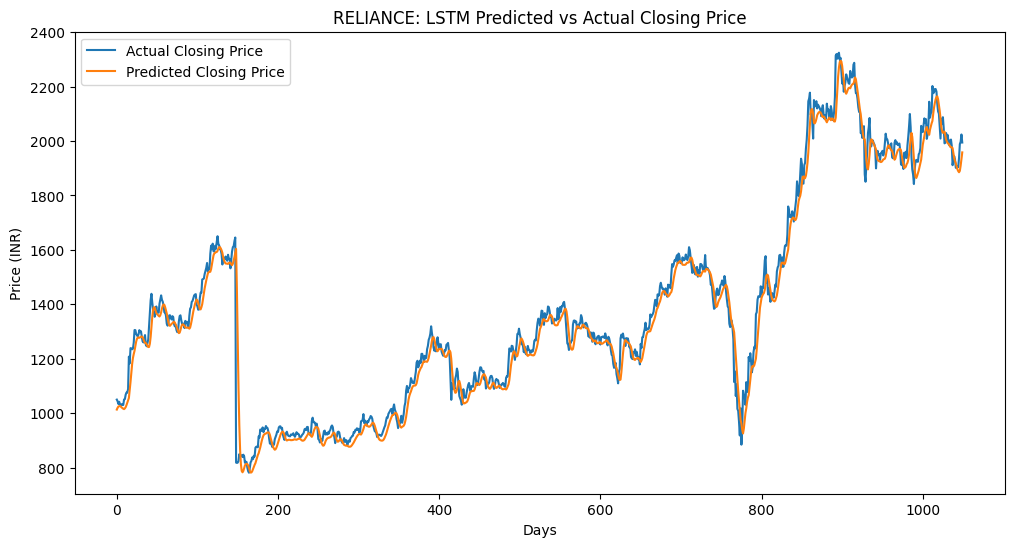

In [10]:
plt.figure(figsize=(12,6))
plt.plot(actual_prices, label='Actual Closing Price')
plt.plot(predicted_prices, label='Predicted Closing Price')
plt.title('RELIANCE: LSTM Predicted vs Actual Closing Price')
plt.xlabel('Days')
plt.ylabel('Price (INR)')
plt.legend()
plt.show()

# Conclusion

- Predicted the next day’s closing price using the past 60 days of closing prices.
- Used an LSTM model, suitable for time series patterns like trend, momentum, and seasonality.
- Dataset split into 80% for training and 20% for testing.